# Logistic Regression Implementation
##  Hands-On with the Titanic Dataset

In this notebook, we'll implement a complete **Logistic Regression** pipeline to predict passenger survival on the Titanic. You'll learn:

1. How to load and explore data
2. How to clean and prepare data for machine learning
3. How to train a Logistic Regression model
4. How to evaluate model performance
5. How to interpret results using confusion matrices and metrics

---

## The Machine Learning Pipeline

Every ML project follows a similar workflow:

```
📥 Load Data → 🧹 Clean Data → ✂️ Split Data → 🎯 Train Model → 🔮 Predict → 📊 Evaluate
```

Let's go through each step!

---
## Step 1: Import Libraries

First, we import all the tools we'll need. Each library serves a specific purpose:

In [8]:
# Data handling
import pandas as pd                  # For loading and manipulating data
import numpy as np                   # For numerical operations

# Machine Learning
from sklearn.model_selection import train_test_split    # Split data into train/test
from sklearn.linear_model import LogisticRegression     # Our classification model

# Model Evaluation
from sklearn.metrics import classification_report       # Precision, Recall, F1-Score
from sklearn.metrics import confusion_matrix            # Confusion matrix
from sklearn.metrics import accuracy_score              # Overall accuracy

# Visualization
import matplotlib.pyplot as plt      # For creating plots
import seaborn as sns                # For beautiful statistical visualizations

# Display settings
plt.style.use('seaborn-v0_8-whitegrid')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


---
## Step 2: Load and Explore the Data

We'll use the famous **Titanic dataset**. Our goal is to predict whether a passenger survived based on features like age, gender, ticket class, etc.

### About the Dataset
- **Survived**: 0 = Did not survive, 1 = Survived (this is our **target variable**)
- **Pclass**: Ticket class (1st, 2nd, or 3rd)
- **Sex**: Gender
- **Age**: Age in years
- **SibSp**: Number of siblings/spouses aboard
- **Parch**: Number of parents/children aboard
- **Fare**: Ticket price
- **Embarked**: Port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton)

In [ ]:
# Load the dataset

data = pd.read_csv('dataset/titanic/titanic.csv')

# Display basic information
print("📊 Dataset Shape:", data.shape)
print(f"   → {data.shape[0]} passengers, {data.shape[1]} features\n")

📊 Dataset Shape: (891, 12)
   → 891 passengers, 12 features



In [11]:
# View the first few rows
print("🔍 First 5 rows of the dataset:")
data.head()

🔍 First 5 rows of the dataset:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [20]:
# changing the casing of columns for consistency
data.columns = data.columns.str.lower()

In [21]:
# Check data types and missing values
print("📋 Dataset Information:")
print("=" * 50)
data.info()

📋 Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   passengerid  891 non-null    int64  
 1   survived     891 non-null    int64  
 2   pclass       891 non-null    int64  
 3   name         891 non-null    object 
 4   sex          891 non-null    object 
 5   age          714 non-null    float64
 6   sibsp        891 non-null    int64  
 7   parch        891 non-null    int64  
 8   ticket       891 non-null    object 
 9   fare         891 non-null    float64
 10  cabin        204 non-null    object 
 11  embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [22]:
# Check for missing values
print("\n❓ Missing Values:")
print("=" * 50)
missing = data.isnull().sum()
missing_pct = (missing / len(data) * 100).round(1)
missing_df = pd.DataFrame({'Missing': missing, 'Percentage': missing_pct})
print(missing_df[missing_df['Missing'] > 0])


❓ Missing Values:
          Missing  Percentage
age           177        19.9
cabin         687        77.1
embarked        2         0.2


In [23]:
# Quick statistics
print("\n📈 Survival Distribution:")
print("=" * 50)
survival_counts = data['survived'].value_counts()
print(f"Did not survive (0): {survival_counts[0]} passengers ({survival_counts[0]/len(data)*100:.1f}%)")
print(f"Survived (1):        {survival_counts[1]} passengers ({survival_counts[1]/len(data)*100:.1f}%)")


📈 Survival Distribution:
Did not survive (0): 549 passengers (61.6%)
Survived (1):        342 passengers (38.4%)


### 💡 Key Observation
The dataset is **imbalanced** — more passengers did not survive than survived. This is important to keep in mind when evaluating our model.

---
## Step 3: Data Cleaning and Preparation

Before we can train our model, we need to:
1. **Handle missing values** — Fill or remove them
2. **Encode categorical variables** — Convert text to numbers
3. **Select relevant features** — Remove unnecessary columns

In [24]:
# Create a copy to work with
df = data.copy()

# Select only the columns we need
# We'll use: survived, pclass, sex, age, sibsp, parch, fare, embarked
columns_to_keep = ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
df = df[columns_to_keep]

print("✅ Selected columns:", list(df.columns))

✅ Selected columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']


### 3.1 Handle Missing Values

In [25]:
# Check missing values in our selected columns
print("❓ Missing values before cleaning:")
print(df.isnull().sum())

❓ Missing values before cleaning:
survived      0
pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
embarked      2
dtype: int64


In [26]:
# Fill missing Age with MEDIAN (robust to outliers)
median_age = df['age'].median()
df['age'].fillna(median_age, inplace=True)
print(f"✅ Filled missing ages with median: {median_age}")

# Fill missing Embarked with MODE (most common value)
mode_embarked = df['embarked'].mode()[0]
df['embarked'].fillna(mode_embarked, inplace=True)
print(f"✅ Filled missing embarked with mode: '{mode_embarked}'")

# Fill missing Fare with MEDIAN
median_fare = df['fare'].median()
df['fare'].fillna(median_fare, inplace=True)
print(f"✅ Filled missing fares with median: {median_fare}")

✅ Filled missing ages with median: 28.0
✅ Filled missing embarked with mode: 'S'
✅ Filled missing fares with median: 14.4542


/tmp/ipython-input-2582985346.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(median_age, inplace=True)
/tmp/ipython-input-2582985346.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'd

In [27]:
# Verify no missing values remain
print("\n❓ Missing values after cleaning:")
print(df.isnull().sum())
print("\n✅ All missing values handled!")


❓ Missing values after cleaning:
survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
dtype: int64

✅ All missing values handled!


### 3.2 Encode Categorical Variables

Machine learning models need **numbers**, not text. We need to convert:
- **Sex**: 'male' → 0, 'female' → 1
- **Embarked**: 'C' → 0, 'Q' → 1, 'S' → 2

In [28]:
# Encode Sex
df['sex'] = df['sex'].map({'male': 0, 'female': 1})
print("✅ Encoded 'sex': male=0, female=1")

# Encode Embarked
df['embarked'] = df['embarked'].map({'C': 0, 'Q': 1, 'S': 2})
print("✅ Encoded 'embarked': C=0, Q=1, S=2")

✅ Encoded 'sex': male=0, female=1
✅ Encoded 'embarked': C=0, Q=1, S=2


In [29]:
# View the cleaned dataset
print("\n🧹 Cleaned Dataset:")
df.head(10)


🧹 Cleaned Dataset:


,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,0,22.0,1,0,7.2500,2
1,1,1,1,38.0,1,0,71.2833,0
2,1,3,1,26.0,0,0,7.9250,2
3,1,1,1,35.0,1,0,53.1000,2
4,0,3,0,35.0,0,0,8.0500,2
5,0,3,0,28.0,0,0,8.4583,1
6,0,1,0,54.0,0,0,51.8625,2
7,0,3,0,2.0,3,1,21.0750,2
8,1,3,1,27.0,0,2,11.1333,2
9,1,2,1,14.0,1,0,30.0708,0


In [30]:
# Final check
print("\n📋 Final Dataset Info:")
print(f"   Shape: {df.shape}")
print(f"   Data types: all numeric ✅")
df.dtypes


📋 Final Dataset Info:
   Shape: (891, 8)
   Data types: all numeric ✅


,0
survived,int64
pclass,int64
sex,int64
age,float64
sibsp,int64
parch,int64
fare,float64
embarked,int64


---
## Step 4: Split Data into Training and Testing Sets

### Why do we split?

We need to evaluate our model on data it has **never seen before**. Think of it like this:

- **Training Set (70%)**: The textbook — the model learns from this
- **Test Set (30%)**: The final exam — we evaluate the model on this

If we test on the same data we trained on, we'd be like a student who memorized the exam answers — they'd do great on that specific test but fail on new questions!

In [31]:
# Separate Features (X) and Target (y)
X = df.drop('survived', axis=1)  # Everything except 'survived'
y = df['survived']               # Just the 'survived' column

print("📊 Features (X):")
print(f"   Shape: {X.shape}")
print(f"   Columns: {list(X.columns)}")
print(f"\n🎯 Target (y):")
print(f"   Shape: {y.shape}")
print(f"   Values: 0 (not survived), 1 (survived)")

📊 Features (X):
   Shape: (891, 7)
   Columns: ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']

🎯 Target (y):
   Shape: (891,)
   Values: 0 (not survived), 1 (survived)


In [32]:
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,      # 30% for testing
    random_state=42     # For reproducibility
)

print("✂️ Data Split Complete!")
print("=" * 50)
print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Testing set:  {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.0f}%)")

✂️ Data Split Complete!
Training set: 623 samples (70%)
Testing set:  268 samples (30%)


In [33]:
# Verify the split maintained class distribution
print("\n📊 Class Distribution Check:")
print(f"Original: {y.value_counts(normalize=True).round(3).to_dict()}")
print(f"Training: {y_train.value_counts(normalize=True).round(3).to_dict()}")
print(f"Testing:  {y_test.value_counts(normalize=True).round(3).to_dict()}")
print("\n✅ Distribution is similar across splits (good!)")


📊 Class Distribution Check:
Original: {0: 0.616, 1: 0.384}
Training: {0: 0.629, 1: 0.371}
Testing:  {0: 0.586, 1: 0.414}

✅ Distribution is similar across splits (good!)


---
## Step 5: Train the Logistic Regression Model

Now for the exciting part — training our model!

The `fit()` method does all the heavy lifting:
- It runs **gradient descent** to find the best weights
- It minimizes the **binary cross-entropy loss**
- The result: optimal weights that map features to survival probability

In [34]:
# Create the model
model = LogisticRegression(
    max_iter=1000,    # Maximum iterations for convergence
    random_state=42   # For reproducibility
)

print("🎯 Model created: LogisticRegression")
print(f"   Max iterations: 1000")

🎯 Model created: LogisticRegression
   Max iterations: 1000


In [35]:
# Train the model
print("🏋️ Training the model...")
model.fit(X_train, y_train)
print("✅ Model trained successfully!")

🏋️ Training the model...
✅ Model trained successfully!


In [36]:
# Examine the learned weights
print("\n⚖️ Learned Feature Weights:")
print("=" * 50)
weights = pd.DataFrame({
    'Feature': X.columns,
    'Weight': model.coef_[0].round(4)
}).sort_values('Weight', key=abs, ascending=False)

print(weights.to_string(index=False))
print(f"\nIntercept (bias): {model.intercept_[0]:.4f}")


⚖️ Learned Feature Weights:
 Feature  Weight
     sex  2.4797
  pclass -0.8924
embarked -0.2921
   sibsp -0.2642
   parch -0.0892
     age -0.0326
    fare  0.0027

Intercept (bias): 2.0442


### 💡 Interpreting the Weights

- **Positive weight** → Increases survival probability
- **Negative weight** → Decreases survival probability
- **Larger absolute value** → Stronger influence

For example:
- `sex` has a positive weight → Being female (1) increases survival chances
- `pclass` has a negative weight → Higher class number (3rd class) decreases survival chances

---
## Step 6: Make Predictions

Now let's use our trained model to make predictions!

In [37]:
# Predict on training data
y_train_pred = model.predict(X_train)

# Predict on test data
y_test_pred = model.predict(X_test)

print("🔮 Predictions Complete!")
print(f"   Training predictions: {len(y_train_pred)}")
print(f"   Test predictions: {len(y_test_pred)}")

🔮 Predictions Complete!
   Training predictions: 623
   Test predictions: 268


In [38]:
# We can also get probability scores
y_test_proba = model.predict_proba(X_test)

print("\n📊 Sample Predictions with Probabilities:")
print("=" * 60)
sample_results = pd.DataFrame({
    'Actual': y_test.head(10).values,
    'Predicted': y_test_pred[:10],
    'P(Not Survive)': y_test_proba[:10, 0].round(3),
    'P(Survive)': y_test_proba[:10, 1].round(3)
})
print(sample_results.to_string(index=False))


📊 Sample Predictions with Probabilities:
 Actual  Predicted  P(Not Survive)  P(Survive)
      1          0           0.865       0.135
      0          0           0.787       0.213
      0          0           0.864       0.136
      1          1           0.123       0.877
      1          1           0.239       0.761
      1          1           0.082       0.918
      1          1           0.340       0.660
      0          0           0.902       0.098
      1          1           0.258       0.742
      1          1           0.089       0.911


---
## Step 7: Evaluate Model Performance

### 7.1 Understanding the Confusion Matrix

A confusion matrix shows us exactly where our model is right and wrong:

```
                    PREDICTED
                 Not Survived | Survived
              ┌───────────────┬──────────┐
    Not       │ True Negative │ False    │
    Survived  │     (TN)      │ Positive │
ACTUAL        │ Correct! ✓    │   (FP)   │
              ├───────────────┼──────────┤
    Survived  │ False         │ True     │
              │ Negative (FN) │ Positive │
              │               │   (TP)   │
              │               │ Correct! ✓│
              └───────────────┴──────────┘
```

- **True Positive (TP)**: Predicted survived, actually survived ✓
- **True Negative (TN)**: Predicted not survived, actually didn't survive ✓
- **False Positive (FP)**: Predicted survived, but actually didn't (Type I Error)
- **False Negative (FN)**: Predicted not survived, but actually survived (Type II Error)

In [39]:
# Calculate accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("📊 Accuracy Scores:")
print("=" * 50)
print(f"Training Accuracy: {train_accuracy:.2%}")
print(f"Test Accuracy:     {test_accuracy:.2%}")

📊 Accuracy Scores:
Training Accuracy: 79.94%
Test Accuracy:     81.34%


### 7.2 Training Set Evaluation

In [40]:
# Confusion Matrix for Training Data
cm_train = confusion_matrix(y_train, y_train_pred)

print("📊 Training Set - Confusion Matrix:")
print("=" * 50)
print(f"\n{cm_train}")
print(f"\nInterpretation:")
print(f"  True Negatives (correctly predicted not survived):  {cm_train[0,0]}")
print(f"  False Positives (incorrectly predicted survived):   {cm_train[0,1]}")
print(f"  False Negatives (incorrectly predicted not survived): {cm_train[1,0]}")
print(f"  True Positives (correctly predicted survived):      {cm_train[1,1]}")

📊 Training Set - Confusion Matrix:

[[340  52]
 [ 73 158]]

Interpretation:
  True Negatives (correctly predicted not survived):  340
  False Positives (incorrectly predicted survived):   52
  False Negatives (incorrectly predicted not survived): 73
  True Positives (correctly predicted survived):      158


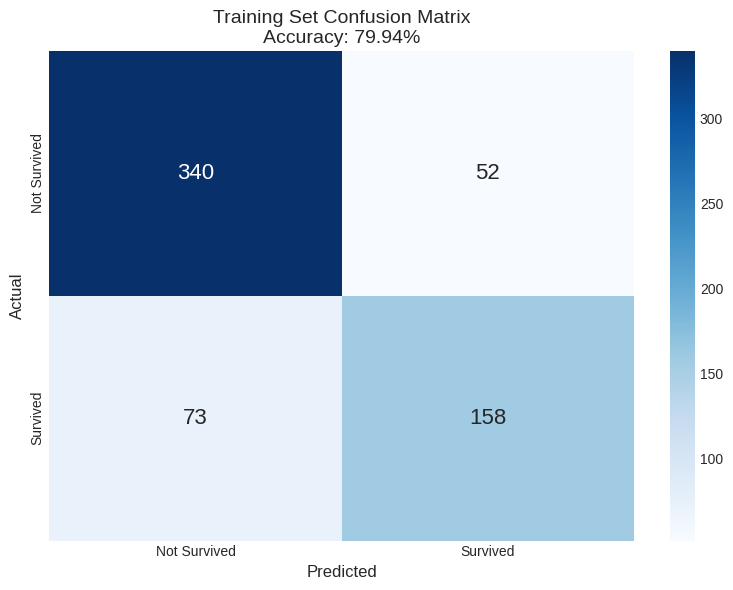

In [41]:
# Visualize Training Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'],
            annot_kws={'size': 16})
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title(f'Training Set Confusion Matrix\nAccuracy: {train_accuracy:.2%}', fontsize=14)
plt.tight_layout()
plt.show()

In [42]:
# Classification Report for Training Data
print("📋 Training Set - Classification Report:")
print("=" * 50)
print(classification_report(y_train, y_train_pred,
                            target_names=['Not Survived', 'Survived']))

📋 Training Set - Classification Report:
              precision    recall  f1-score   support

Not Survived       0.82      0.87      0.84       392
    Survived       0.75      0.68      0.72       231

    accuracy                           0.80       623
   macro avg       0.79      0.78      0.78       623
weighted avg       0.80      0.80      0.80       623



### 7.3 Test Set Evaluation

In [43]:
# Confusion Matrix for Test Data
cm_test = confusion_matrix(y_test, y_test_pred)

print("📊 Test Set - Confusion Matrix:")
print("=" * 50)
print(f"\n{cm_test}")
print(f"\nInterpretation:")
print(f"  True Negatives (correctly predicted not survived):  {cm_test[0,0]}")
print(f"  False Positives (incorrectly predicted survived):   {cm_test[0,1]}")
print(f"  False Negatives (incorrectly predicted not survived): {cm_test[1,0]}")
print(f"  True Positives (correctly predicted survived):      {cm_test[1,1]}")

📊 Test Set - Confusion Matrix:

[[137  20]
 [ 30  81]]

Interpretation:
  True Negatives (correctly predicted not survived):  137
  False Positives (incorrectly predicted survived):   20
  False Negatives (incorrectly predicted not survived): 30
  True Positives (correctly predicted survived):      81


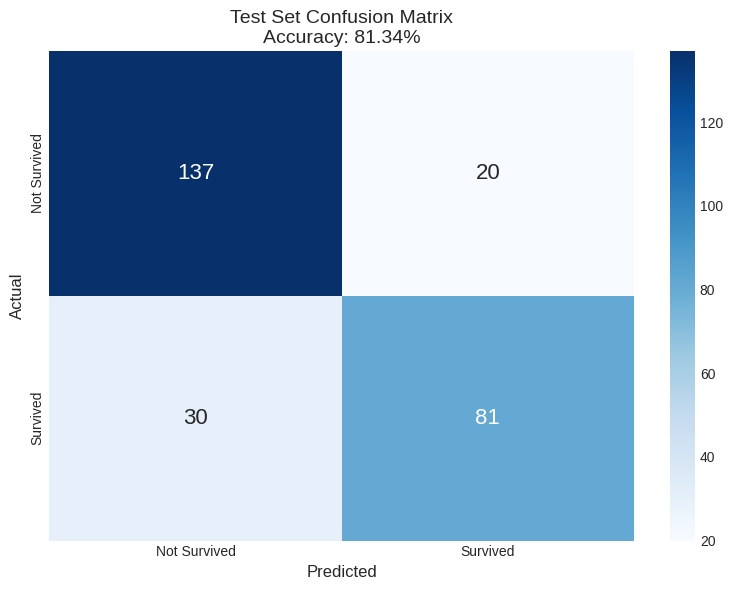

In [44]:
# Visualize Test Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'],
            annot_kws={'size': 16})
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title(f'Test Set Confusion Matrix\nAccuracy: {test_accuracy:.2%}', fontsize=14)
plt.tight_layout()
plt.show()

In [45]:
# Classification Report for Test Data
print("📋 Test Set - Classification Report:")
print("=" * 50)
print(classification_report(y_test, y_test_pred,
                            target_names=['Not Survived', 'Survived']))

📋 Test Set - Classification Report:
              precision    recall  f1-score   support

Not Survived       0.82      0.87      0.85       157
    Survived       0.80      0.73      0.76       111

    accuracy                           0.81       268
   macro avg       0.81      0.80      0.80       268
weighted avg       0.81      0.81      0.81       268



### 7.4 Side-by-Side Comparison

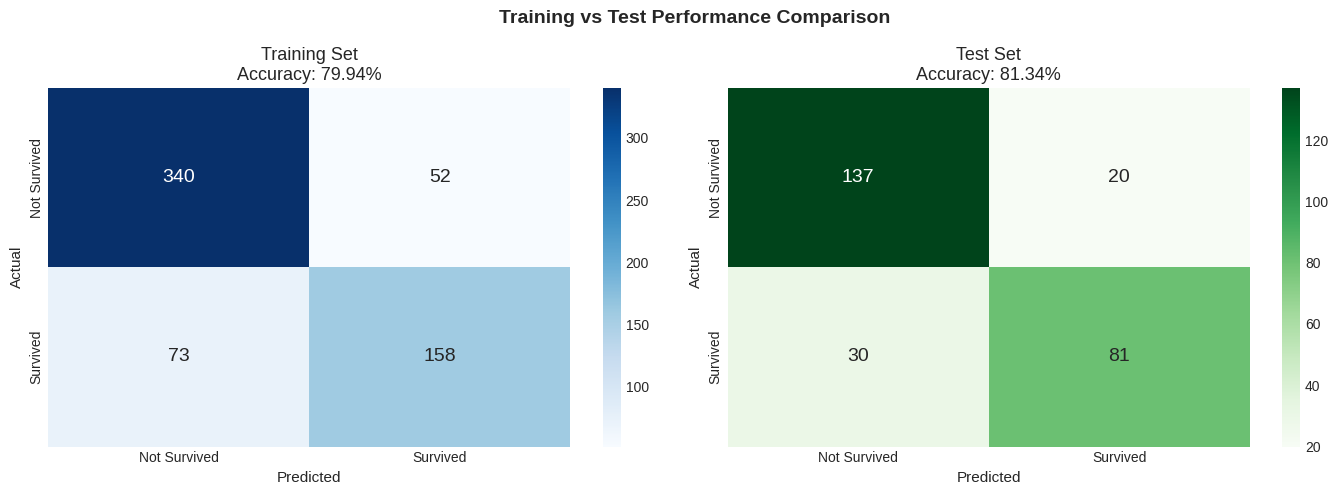

In [46]:
# Compare Training vs Test Performance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'],
            annot_kws={'size': 14})
axes[0].set_xlabel('Predicted', fontsize=11)
axes[0].set_ylabel('Actual', fontsize=11)
axes[0].set_title(f'Training Set\nAccuracy: {train_accuracy:.2%}', fontsize=13)

# Test
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'],
            annot_kws={'size': 14})
axes[1].set_xlabel('Predicted', fontsize=11)
axes[1].set_ylabel('Actual', fontsize=11)
axes[1].set_title(f'Test Set\nAccuracy: {test_accuracy:.2%}', fontsize=13)

plt.suptitle('Training vs Test Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 8: Understanding the Metrics

Let's break down what each metric means:

In [47]:
# Calculate metrics manually for understanding
TN, FP, FN, TP = cm_test.ravel()

print("📊 Understanding the Metrics (Test Set):")
print("=" * 60)

# Accuracy
accuracy = (TP + TN) / (TP + TN + FP + FN)
print(f"\n1️⃣ ACCURACY: {accuracy:.2%}")
print(f"   Formula: (TP + TN) / Total = ({TP} + {TN}) / {TP+TN+FP+FN}")
print(f"   Meaning: Overall, how often is the model correct?")

# Precision for Survived class
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
print(f"\n2️⃣ PRECISION (Survived): {precision:.2%}")
print(f"   Formula: TP / (TP + FP) = {TP} / ({TP} + {FP})")
print(f"   Meaning: When we predict 'survived', how often are we right?")

# Recall for Survived class
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
print(f"\n3️⃣ RECALL (Survived): {recall:.2%}")
print(f"   Formula: TP / (TP + FN) = {TP} / ({TP} + {FN})")
print(f"   Meaning: Of all actual survivors, how many did we find?")

# F1-Score
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
print(f"\n4️⃣ F1-SCORE (Survived): {f1:.2%}")
print(f"   Formula: 2 × (Precision × Recall) / (Precision + Recall)")
print(f"   Meaning: Harmonic mean of precision and recall (balanced measure)")

📊 Understanding the Metrics (Test Set):

1️⃣ ACCURACY: 81.34%
   Formula: (TP + TN) / Total = (81 + 137) / 268
   Meaning: Overall, how often is the model correct?

2️⃣ PRECISION (Survived): 80.20%
   Formula: TP / (TP + FP) = 81 / (81 + 20)
   Meaning: When we predict 'survived', how often are we right?

3️⃣ RECALL (Survived): 72.97%
   Formula: TP / (TP + FN) = 81 / (81 + 30)
   Meaning: Of all actual survivors, how many did we find?

4️⃣ F1-SCORE (Survived): 76.42%
   Formula: 2 × (Precision × Recall) / (Precision + Recall)
   Meaning: Harmonic mean of precision and recall (balanced measure)


### 💡 When to Use Which Metric?

| Metric | Use When... | Example |
|--------|-------------|----------|
| **Accuracy** | Classes are balanced | General performance |
| **Precision** | False Positives are costly | Spam detection (don't want to lose important emails) |
| **Recall** | False Negatives are costly | Disease diagnosis (don't want to miss sick patients) |
| **F1-Score** | You need balance between precision and recall | Most classification tasks |

---
## Step 9: Check for Overfitting

**Overfitting** occurs when a model performs well on training data but poorly on new (test) data. Let's check if our model overfits:

In [48]:
print("🔍 Overfitting Analysis:")
print("=" * 50)
print(f"Training Accuracy: {train_accuracy:.2%}")
print(f"Test Accuracy:     {test_accuracy:.2%}")
print(f"Difference:        {abs(train_accuracy - test_accuracy):.2%}")

print("\n📋 Interpretation:")
if abs(train_accuracy - test_accuracy) < 0.05:
    print("✅ Good! Training and test accuracy are similar.")
    print("   The model generalizes well to unseen data.")
    print("   No significant overfitting detected.")
elif train_accuracy > test_accuracy + 0.05:
    print("⚠️ Warning! Training accuracy is much higher than test accuracy.")
    print("   This suggests overfitting - the model memorized training data.")
else:
    print("🤔 Unusual - test accuracy is higher than training accuracy.")
    print("   This could be due to data variance or lucky test split.")

🔍 Overfitting Analysis:
Training Accuracy: 79.94%
Test Accuracy:     81.34%
Difference:        1.41%

📋 Interpretation:
✅ Good! Training and test accuracy are similar.
   The model generalizes well to unseen data.
   No significant overfitting detected.


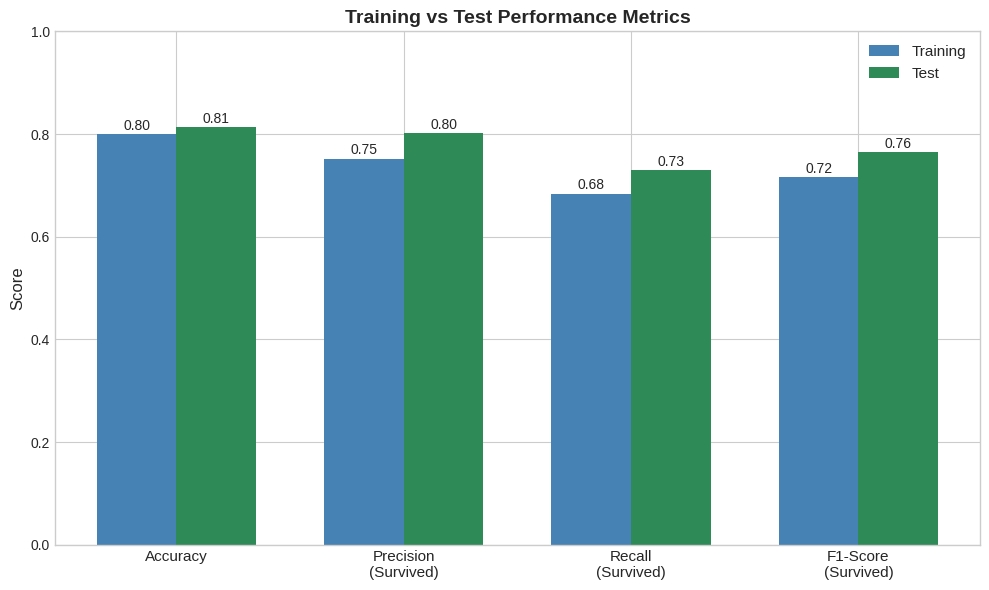

In [49]:
# Visual comparison
metrics = ['Accuracy', 'Precision\n(Survived)', 'Recall\n(Survived)', 'F1-Score\n(Survived)']

# Get metrics from classification reports
from sklearn.metrics import precision_recall_fscore_support

train_p, train_r, train_f, _ = precision_recall_fscore_support(y_train, y_train_pred, average='binary')
test_p, test_r, test_f, _ = precision_recall_fscore_support(y_test, y_test_pred, average='binary')

train_metrics = [train_accuracy, train_p, train_r, train_f]
test_metrics = [test_accuracy, test_p, test_r, test_f]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, train_metrics, width, label='Training', color='steelblue')
bars2 = ax.bar(x + width/2, test_metrics, width, label='Test', color='seagreen')

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Training vs Test Performance Metrics', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim(0, 1)

# Add value labels
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', fontsize=10)
for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

---
## Step 10: Make Predictions on New Data

Let's see how to use our model to predict survival for new passengers!

In [50]:
# Create some hypothetical passengers
new_passengers = pd.DataFrame({
    'pclass': [1, 3, 2],
    'sex': [1, 0, 1],           # 1=female, 0=male
    'age': [25, 35, 8],
    'sibsp': [1, 0, 2],
    'parch': [0, 0, 2],
    'fare': [100, 8, 30],
    'embarked': [0, 2, 1]       # 0=C, 1=Q, 2=S
})

print("👥 New Passengers to Predict:")
print("=" * 60)
passenger_desc = [
    "Passenger 1: 25-year-old female, 1st class, fare $100",
    "Passenger 2: 35-year-old male, 3rd class, fare $8",
    "Passenger 3: 8-year-old female child, 2nd class, fare $30"
]
for desc in passenger_desc:
    print(f"  • {desc}")

👥 New Passengers to Predict:
  • Passenger 1: 25-year-old female, 1st class, fare $100
  • Passenger 2: 35-year-old male, 3rd class, fare $8
  • Passenger 3: 8-year-old female child, 2nd class, fare $30


In [51]:
# Make predictions
predictions = model.predict(new_passengers)
probabilities = model.predict_proba(new_passengers)

print("\n🔮 Predictions:")
print("=" * 60)
for i, (pred, prob, desc) in enumerate(zip(predictions, probabilities, passenger_desc)):
    survival = "SURVIVED ✅" if pred == 1 else "NOT SURVIVED ❌"
    print(f"\n{desc}")
    print(f"   Prediction: {survival}")
    print(f"   Confidence: {max(prob)*100:.1f}%")
    print(f"   (P(Not Survive)={prob[0]:.2f}, P(Survive)={prob[1]:.2f})")


🔮 Predictions:

Passenger 1: 25-year-old female, 1st class, fare $100
   Prediction: SURVIVED ✅
   Confidence: 94.4%
   (P(Not Survive)=0.06, P(Survive)=0.94)

Passenger 2: 35-year-old male, 3rd class, fare $8
   Prediction: NOT SURVIVED ❌
   Confidence: 91.2%
   (P(Not Survive)=0.91, P(Survive)=0.09)

Passenger 3: 8-year-old female child, 2nd class, fare $30
   Prediction: SURVIVED ✅
   Confidence: 82.7%
   (P(Not Survive)=0.17, P(Survive)=0.83)


---
## 📝 Summary

### What We Learned

1. **Data Preparation**: Clean data, handle missing values, encode categories
2. **Train/Test Split**: Always evaluate on unseen data (70/30 or 80/20)
3. **Model Training**: `LogisticRegression().fit(X_train, y_train)`
4. **Predictions**: `model.predict()` for classes, `model.predict_proba()` for probabilities
5. **Evaluation**: Use confusion matrix, accuracy, precision, recall, F1-score
6. **Overfitting Check**: Compare training vs test performance

### Our Model's Performance
- **~80% accuracy** on both training and test sets
- **No significant overfitting** — model generalizes well
- **Better at predicting non-survivors** (higher precision for class 0)

### Key Takeaways
- Logistic Regression is simple but effective for binary classification
- Feature weights show which factors matter most (sex, class were important)
- Always check for overfitting by comparing train/test performance

---
## 🎯 Practice Exercises

Try these on your own:

1. **Change the test size**: Try `test_size=0.2` (80/20 split). How does it affect accuracy?

2. **Add more features**: Include 'deck' or create 'family_size' = sibsp + parch. Does it improve the model?

3. **Try different thresholds**: Instead of the default 0.5, what if we predict 'survived' when probability > 0.3?

4. **Feature importance**: Which feature has the highest absolute weight? What does this tell us?

In [52]:
# Your practice code here!
# Exercise 1: Try a different test_size

